# Figure 1e

This notebook recreates the visualization shown in figure 1e in the reference article.

> Same t-SNE plot as (C) [t-SNE plot of the integrated scRNA-seq profiles of epithelial cells form 11 reduction mammoplasties.] but colored by cell clusters (with Suerat cluster resolution set to 0.015)

<div style="text-align: center;">
    <img src="images/figure-1e-reference.png" alt="Figure 1e from Reference Article" width="50%">
    <p style="font-size:90%; color:gray; text-align: center;"><em>Figure 1e from Reference Article</em></p>
</div>

## 0. Initializations

In [1]:
# -- imports --
from signals_in_the_noise.preprocessing.gse161529 import GSE161529
from signals_in_the_noise.utils.visualization import get_figure_axes

In [2]:
# -- dataset --
gse = GSE161529()
all_real, all_noise = gse.get_combined_epithelial_dataset(real_pca_kwargs={}, noise_pca_kwargs={}, hvg_post_stromal=True)

## 1. "Real" cells

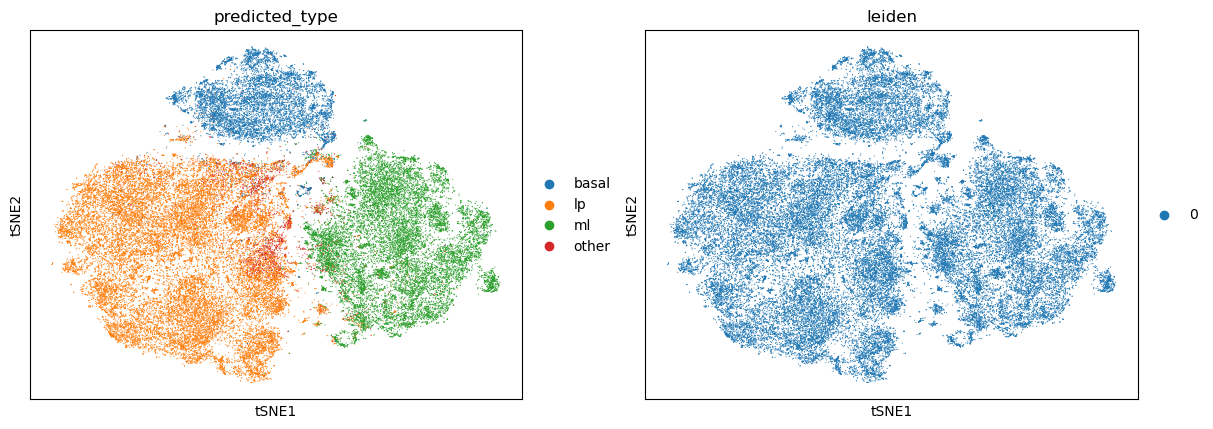

In [3]:
gse.visualize_tsne(all_real, color=['predicted_type', 'leiden'])

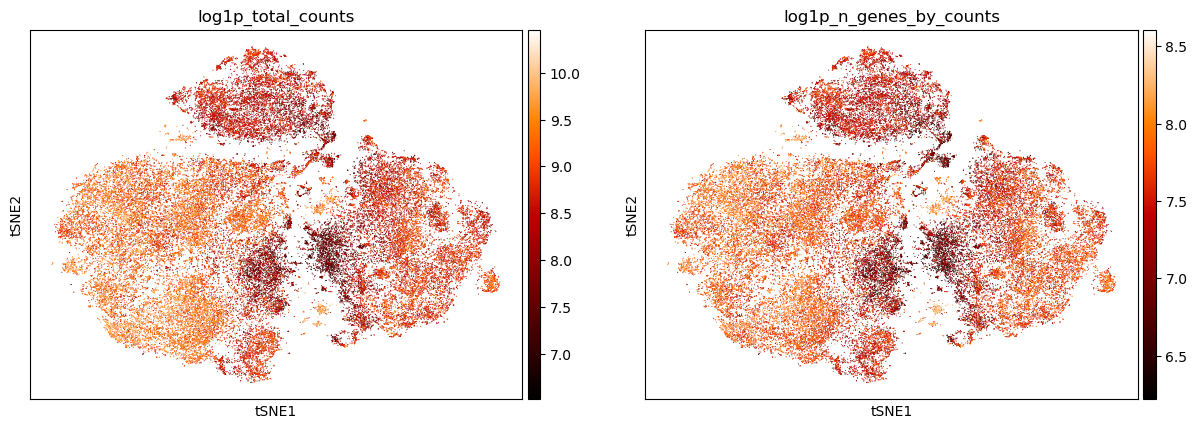

In [4]:
gse.visualize_tsne(all_real, color=['log1p_total_counts', 'log1p_n_genes_by_counts'], plot_kwargs={'cmap': 'gist_heat'})

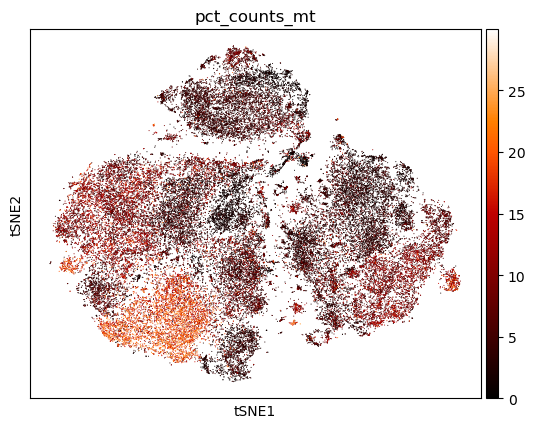

In [5]:
gse.visualize_tsne(all_real, color=['pct_counts_mt'], plot_kwargs={'cmap': 'gist_heat'})

## 2. "Noise" cells

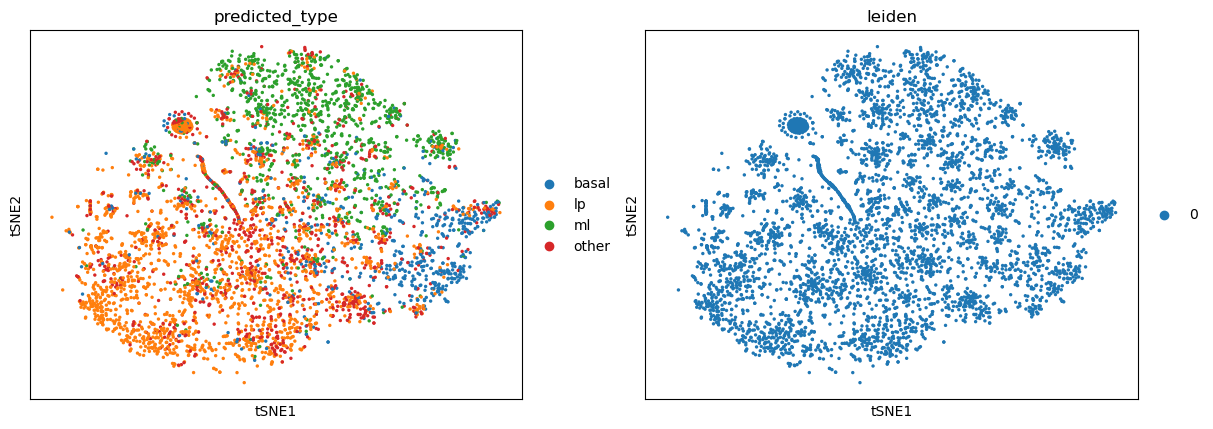

In [6]:
gse.visualize_tsne(all_noise, color=['predicted_type', 'leiden'])

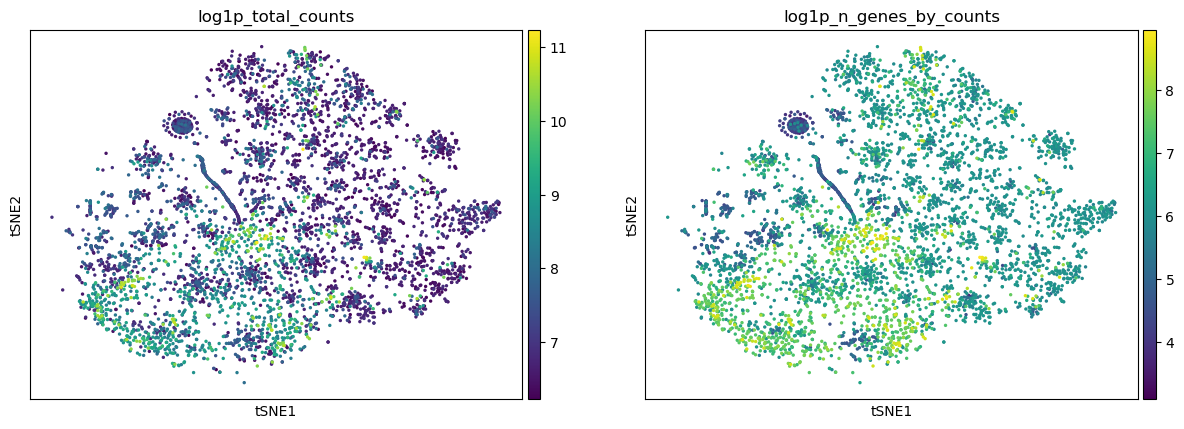

In [7]:
gse.visualize_tsne(all_noise, color=['log1p_total_counts', 'log1p_n_genes_by_counts'])

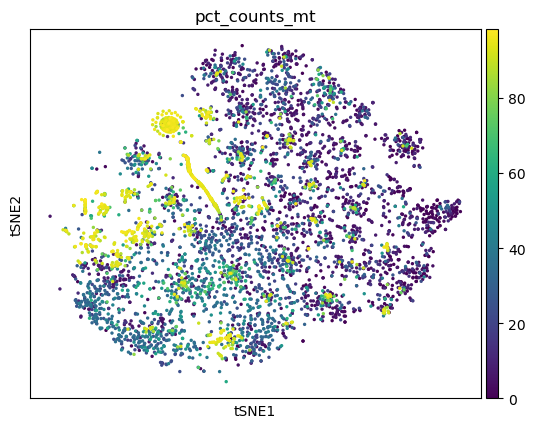

In [8]:
gse.visualize_tsne(all_noise, color=['pct_counts_mt'])

#### 2.a. Gather numbers for paper

In [9]:
from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes

classify_noise_subtypes(all_noise)

AnnData object with n_obs × n_vars = 5014 × 51
    obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'EPCAM_expr', 'KRT5_expr', 'ACTA2_expr', 'MYLK_expr', 'SNAI2_expr', 'NOTCH4_expr', 'DKK3_expr', 'CD49f_expr', 'ESR1_expr', 'PGR_expr', 'FOXA1_expr', 'TNFRSF11A_expr', 'KIT_expr', 'SOX10_expr', 'score_basal', 'score_lp', 'score_ml', 'score_stromal', 'predicted_type', 'predicted_type_score', 'score_other', 'specimen_id', 'hormonal_status', 'cancer_type', 'cell_population', 'gender', 'parity', 'leiden', 'pbs-1', 'pbs-2', 'pbs-3'
    var: 'mean', 'std'
    uns: 'leiden', 'neighbors', 'pca', 'predicted_type_colors', 'leide

In [10]:
# classification is handled by classify_noise_subtypes above

In [11]:
(all_noise.shape[0],
 all_noise.obs['pbs-1'].sum(),
 all_noise.obs['pbs-1'].sum()/all_noise.shape[0],
 all_noise.obs['pbs-2'].sum(),
 all_noise.obs['pbs-2'].sum()/all_noise.shape[0],
 all_noise.obs['pbs-3'].sum(),
 all_noise.obs['pbs-3'].sum()/all_noise.shape[0],
 )

(5014,
 np.int64(214),
 np.float64(0.04268049461507778),
 np.int64(539),
 np.float64(0.10749900279218189),
 np.int64(115),
 np.float64(0.022935779816513763))

In [12]:
all_noise.obs[all_noise.obs['pbs-1'] == 1][['is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count']].describe().loc['max', :]

is_low_num_genes       1.0
is_high_num_genes      0.0
is_high_mito           1.0
is_high_total_count    0.0
Name: max, dtype: float64

In [13]:
all_noise.obs[all_noise.obs['pbs-2'] == 1][['is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count']].describe().loc['max', :]

is_low_num_genes       1.0
is_high_num_genes      0.0
is_high_mito           0.0
is_high_total_count    0.0
Name: max, dtype: float64

In [14]:
all_noise.obs[all_noise.obs['pbs-3'] == 1][['is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count']].describe().loc['max', :]

is_low_num_genes       0.0
is_high_num_genes      0.0
is_high_mito           1.0
is_high_total_count    0.0
Name: max, dtype: float64

### 3. UMAPs

In [15]:
import scanpy as sc
sc.tl.umap(all_noise)
sc.tl.umap(all_real)

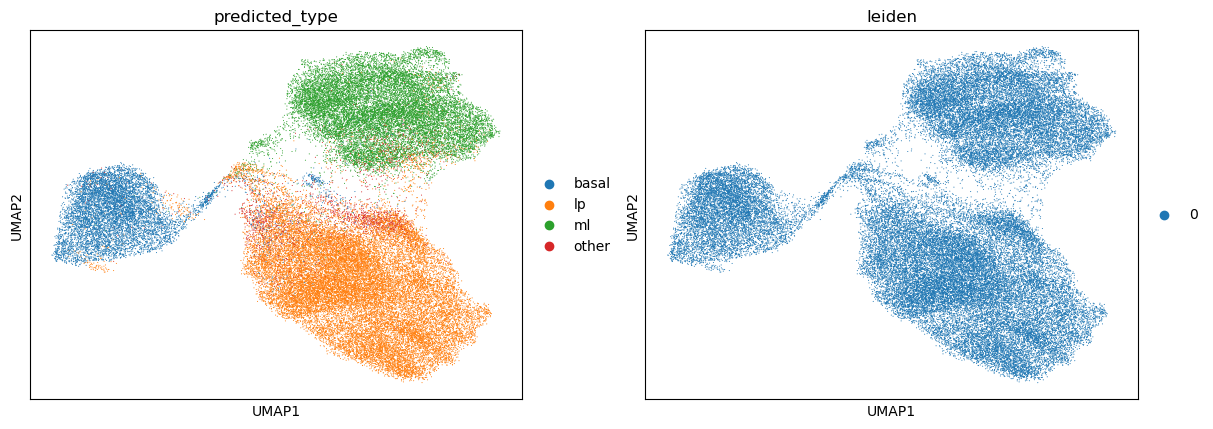

In [16]:
sc.pl.umap(all_real, color=['predicted_type', 'leiden'])

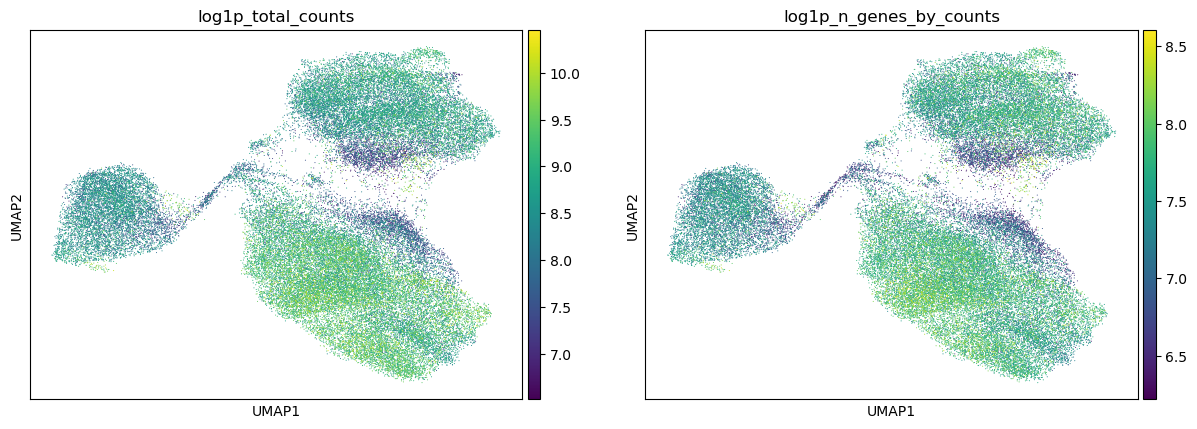

In [17]:
sc.pl.umap(all_real, color=['log1p_total_counts', 'log1p_n_genes_by_counts'])

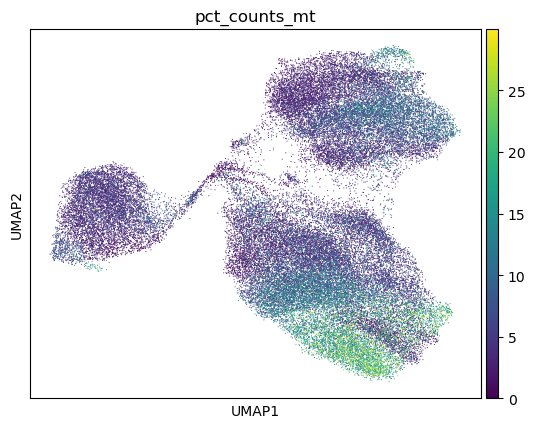

In [18]:
sc.pl.umap(all_real, color=['pct_counts_mt'])

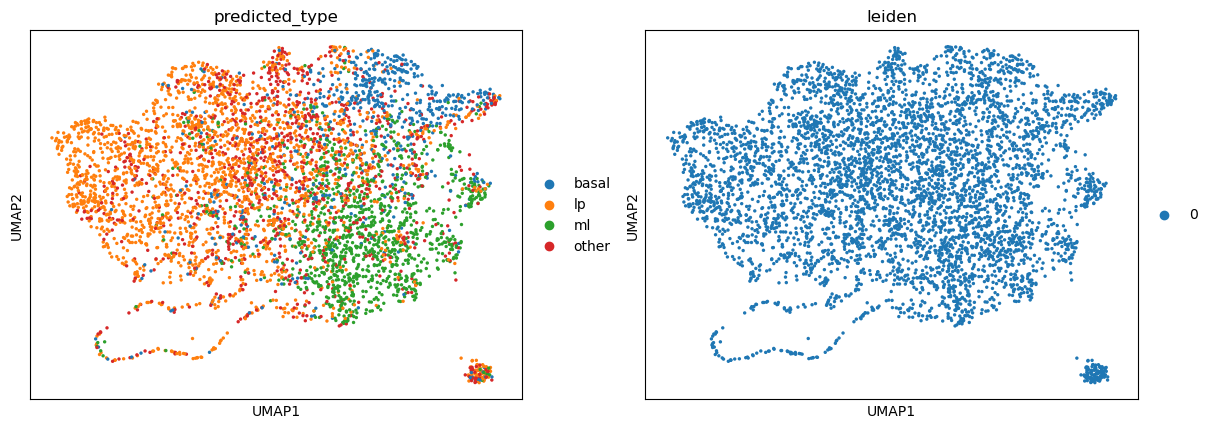

In [19]:
sc.pl.umap(all_noise, color=['predicted_type', 'leiden'])

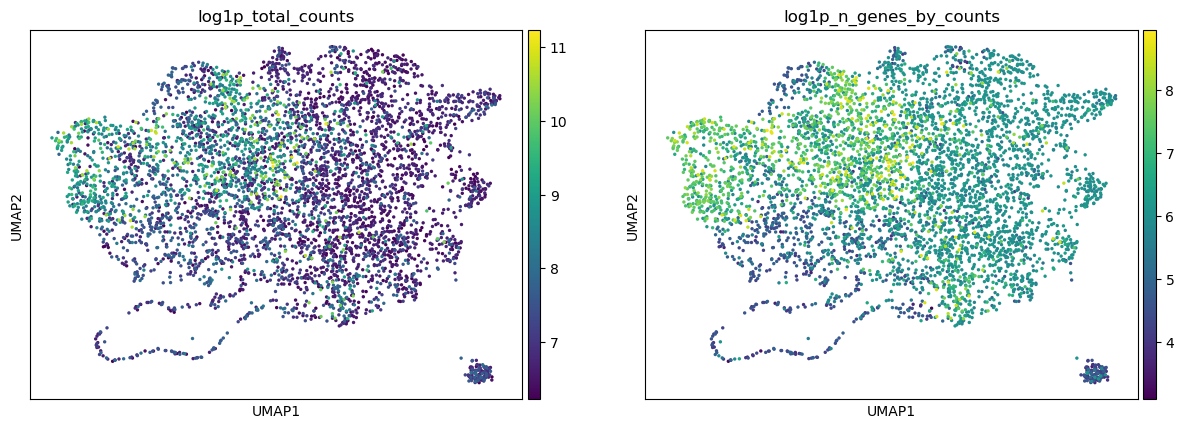

In [20]:
sc.pl.umap(all_noise, color=['log1p_total_counts', 'log1p_n_genes_by_counts'])

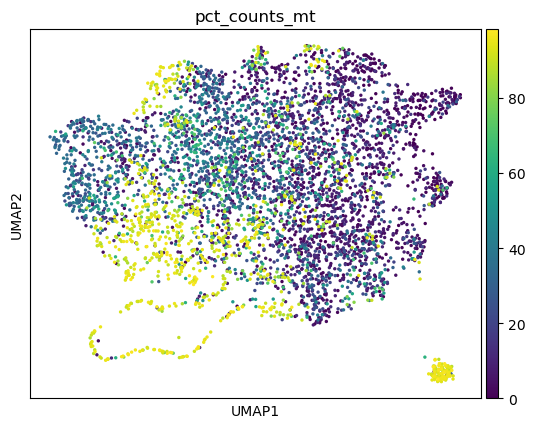

In [21]:
sc.pl.umap(all_noise, color=['pct_counts_mt'])

## for expo poster

In [22]:
from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes

initial = {
    'q_low': 0.25,
    'q_high': 0.75
}
variation = initial.copy()
variation.update({
    'q_high': 0.95
})

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

palette_a = [
    "#000000",  # cat 1 — black (anchor)
    "#0072B2",  # cat 2 — blue
    "#009E73",  # cat 3 — bluish green
    "#56B4E9",  # cat 4 — sky blue
    "#CC79A7",  # cat 5 — reddish purple
    "#E69F00",  # cat 6 — yellow-orange
    "#D55E00",  # cat 7 — vermillion (anchor)
]

pal_orange = "#D55E00"
pal_blue = "#0072B2"
pal_green = "#009E73"
pal_black = "#000000"
sns.set_palette(palette_a)

In [24]:
import pandas as pd

classify_noise_subtypes(all_noise, **variation)
# UMAP coordinates are stored here after sc.tl.umap(adata)
umap_coords = pd.DataFrame(
    all_noise.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=all_noise.obs_names
)
all_noise

AnnData object with n_obs × n_vars = 5014 × 51
    obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'EPCAM_expr', 'KRT5_expr', 'ACTA2_expr', 'MYLK_expr', 'SNAI2_expr', 'NOTCH4_expr', 'DKK3_expr', 'CD49f_expr', 'ESR1_expr', 'PGR_expr', 'FOXA1_expr', 'TNFRSF11A_expr', 'KIT_expr', 'SOX10_expr', 'score_basal', 'score_lp', 'score_ml', 'score_stromal', 'predicted_type', 'predicted_type_score', 'score_other', 'specimen_id', 'hormonal_status', 'cancer_type', 'cell_population', 'gender', 'parity', 'leiden', 'pbs-1', 'pbs-2', 'pbs-3'
    var: 'mean', 'std'
    uns: 'leiden', 'neighbors', 'pca', 'predicted_type_colors', 'leide

In [38]:
rna_lo = all_noise.obs["log1p_total_counts"].quantile(variation['q_low'])
rna_hi = all_noise.obs["log1p_total_counts"].quantile(variation['q_high'])
mito_lo = all_noise.obs["pct_counts_mt"].quantile(variation['q_low'])
mito_hi = all_noise.obs["pct_counts_mt"].quantile(variation['q_high'])
gene_lo = all_noise.obs["log1p_n_genes_by_counts"].quantile(variation['q_low'])
gene_hi = all_noise.obs["log1p_n_genes_by_counts"].quantile(variation['q_high'])

In [56]:
mask_rna_lo = all_noise.obs["log1p_total_counts"] <= rna_lo
mask_mito_lo = all_noise.obs["pct_counts_mt"] <= mito_lo
mask_mito_high = all_noise.obs["pct_counts_mt"] >= mito_hi
mask_rna_moderate = (all_noise.obs["log1p_total_counts"] > rna_lo) & (all_noise.obs["log1p_total_counts"] < rna_hi)
mask_mito_moderate = (all_noise.obs["pct_counts_mt"] > mito_lo) & (all_noise.obs["pct_counts_mt"] < mito_hi)
mask_gene_high = all_noise.obs["log1p_n_genes_by_counts"] >= gene_hi
mask_gene_low = all_noise.obs["log1p_n_genes_by_counts"] <= gene_lo

In [57]:
all_noise.obs['is_rna_low'] = mask_rna_lo.astype(bool)
all_noise.obs['is_mito_low'] = mask_mito_lo.astype(bool)
all_noise.obs['is_gene_moderate'] = mask_gene_moderate.astype(bool)
all_noise.obs['is_rna_moderate'] = mask_rna_moderate.astype(bool)
all_noise.obs['is_mito_moderate'] = mask_mito_moderate.astype(bool)
all_noise.obs['is_gene_high'] = mask_gene_high.astype(bool)
all_noise.obs['is_mito_high'] = mask_mito_high.astype(bool)
all_noise.obs['is_gene_low'] = mask_gene_low.astype(bool)

In [46]:
all_noise.obs["is_pbs"] = (
    all_noise.obs['pbs-1']
    | all_noise.obs['pbs-2']
    | all_noise.obs['pbs-3']
)

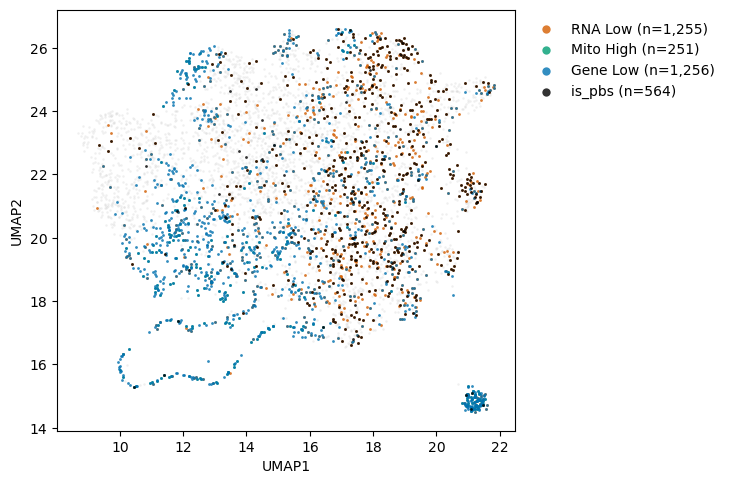

In [54]:
plot_df = umap_coords.copy()
signal = "is_pbs"
for column in [
    "is_rna_low",
    "is_mito_high",
    "is_gene_low",
    signal,
]:
    plot_df[column] = all_noise.obs[column].values

layers = [
    ("is_rna_low", "#D55E00", "RNA Low"),
    ("is_mito_high", "#009E73", "Mito High"),
    ("is_gene_low", "#0072B2", "Gene Low"),
    (signal, "#000000", signal),
]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df["UMAP1"], 
    plot_df["UMAP2"],
    c="#CCCCCC",
    s=3,
    linewidths=0,
    alpha=0.3,
    rasterized=True,
)

for column, color, label in layers:
    subset = plot_df[plot_df[column] == True]
    ax.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        c=color,
        s=4,
        linewidths=0,
        alpha=0.8,
        label=f"{label} (n={len(subset):,})",
        rasterized=True,
    )

ax.set_aspect("equal")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(
    bbox_to_anchor=(1.01, 1), 
    loc="upper left", 
    frameon=False,
    markerscale=3,
)
plt.tight_layout()
plt.show()

In [59]:
rna_lo = all_real.obs["log1p_total_counts"].quantile(variation['q_low'])
rna_hi = all_real.obs["log1p_total_counts"].quantile(variation['q_high'])
mito_lo = all_real.obs["pct_counts_mt"].quantile(variation['q_low'])
mito_hi = all_real.obs["pct_counts_mt"].quantile(variation['q_high'])
gene_lo = all_real.obs["log1p_n_genes_by_counts"].quantile(variation['q_low'])
gene_hi = all_real.obs["log1p_n_genes_by_counts"].quantile(variation['q_high'])
mask_rna_lo = all_real.obs["log1p_total_counts"] <= rna_lo
mask_mito_lo = all_real.obs["pct_counts_mt"] <= mito_lo
mask_mito_high = all_real.obs["pct_counts_mt"] >= mito_hi
mask_rna_moderate = (all_real.obs["log1p_total_counts"] > rna_lo) & (all_real.obs["log1p_total_counts"] < rna_hi)
mask_mito_moderate = (all_real.obs["pct_counts_mt"] > mito_lo) & (all_real.obs["pct_counts_mt"] < mito_hi)
mask_gene_high = all_real.obs["log1p_n_genes_by_counts"] >= gene_hi
mask_gene_low = all_real.obs["log1p_n_genes_by_counts"] <= gene_lo
all_real.obs['is_rna_low'] = mask_rna_lo.astype(bool)
all_real.obs['is_mito_low'] = mask_mito_lo.astype(bool)
all_real.obs['is_gene_moderate'] = mask_gene_moderate.astype(bool)
all_real.obs['is_rna_moderate'] = mask_rna_moderate.astype(bool)
all_real.obs['is_mito_moderate'] = mask_mito_moderate.astype(bool)
all_real.obs['is_gene_high'] = mask_gene_high.astype(bool)
all_real.obs['is_mito_high'] = mask_mito_high.astype(bool)
all_real.obs['is_gene_low'] = mask_gene_low.astype(bool)

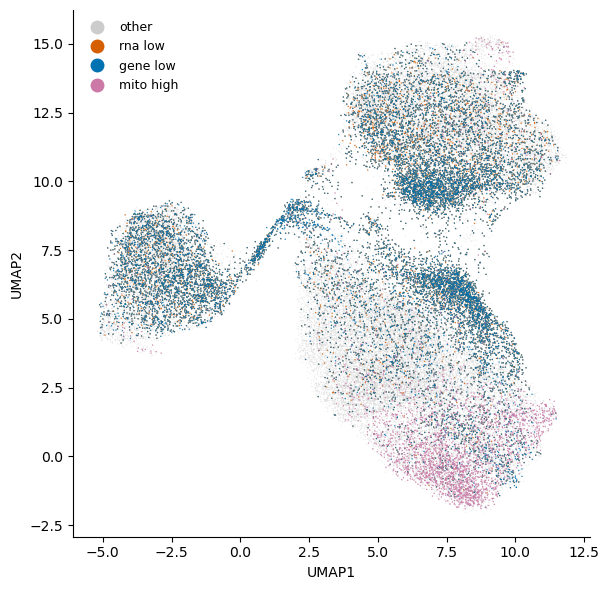

In [126]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# build plot_df from all_real (based on your sc.pl.umap calls)
plot_df = pd.DataFrame(
    all_real.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=all_real.obs_names
)
plot_df["log1p_total_counts"]  = all_real.obs["log1p_total_counts"].values
plot_df["log1p_n_genes_by_counts"] = all_real.obs["log1p_n_genes_by_counts"].values
plot_df["pct_counts_mt"]       = all_real.obs["pct_counts_mt"].values
plot_df["is_mito_high"]        = all_real.obs["is_mito_high"].values
plot_df["is_gene_low"]         = all_real.obs["is_gene_low"].values
# add your third mask here
plot_df["is_rna_low"]          = all_real.obs["is_rna_low"].values

fig, ax = plt.subplots(figsize=(7, 6))

# gray background
ax.scatter(
    plot_df["UMAP1"], plot_df["UMAP2"],
    c="#CCCCCC", s=1, linewidths=0, alpha=0.3, rasterized=True
)

layers = [
    ("is_rna_low",   "log1p_total_counts",       "#D55E00", "rna low"),
    ("is_gene_low",  "log1p_n_genes_by_counts",   "#0072B2", "gene low"),
    ("is_mito_high", "pct_counts_mt",             "#CC79A7", "mito high"),
]

for mask_col, val_col, color, label in layers:
    subset = plot_df[plot_df[mask_col]]
    vals   = subset[val_col].values

    # normalize magnitude → alpha (0.4 low end, 1.0 high end)
    norm        = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
    alphas      = 0.4 + 0.6 * norm(vals)
    alphas = np.array(alphas, dtype=float)
    # scatter with per-point alpha via RGBA
    rgb   = mcolors.to_rgb(color)
    rgba  = np.column_stack([
        np.full(len(subset), rgb[0]),
        np.full(len(subset), rgb[1]),
        np.full(len(subset), rgb[2]),
        alphas
    ])

    ax.scatter(
        subset["UMAP1"], subset["UMAP2"],
        c=rgba, s=1, linewidths=0, alpha=0.85,rasterized=True
    )

# clean manual legend — no colorbars
legend_handles = [
    mlines.Line2D([], [], color="#CCCCCC", marker="o", linestyle="None",
                  markersize=6, label="other"),
    mlines.Line2D([], [], color="#D55E00", marker="o", linestyle="None",
                  markersize=6, label="rna low"),
    mlines.Line2D([], [], color="#0072B2", marker="o", linestyle="None",
                  markersize=6, label="gene low"),
    mlines.Line2D([], [], color="#CC79A7", marker="o", linestyle="None",
                  markersize=6, label="mito high"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",           # inside the plot, top-left void
    frameon=False,
    fontsize=9,
    markerscale=1.5
)

ax.set_aspect("equal")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("images/umsi-expo-figure-3.png", dpi=300, bbox_inches="tight")
plt.show()

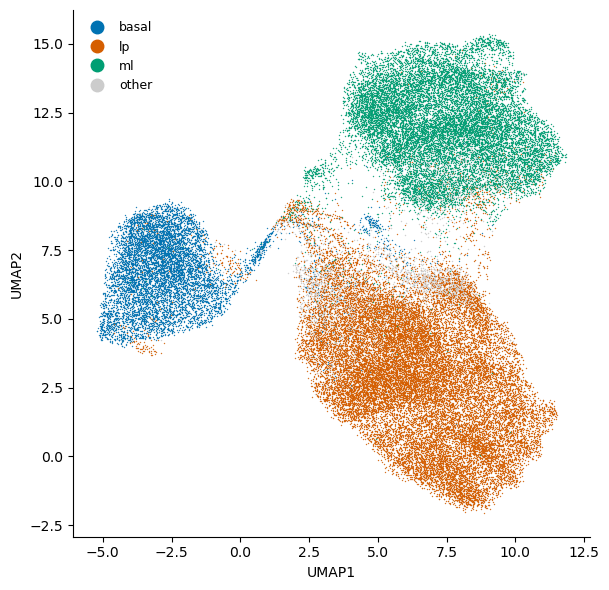

In [125]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

plot_df = pd.DataFrame(
    all_real.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=all_real.obs_names
)
plot_df["predicted_type"] = all_real.obs["predicted_type"].values

# map your categories to Wong palette
type_colors = {
    "basal" : "#0072B2",  # blue
    "lp"    : "#D55E00",  # orange
    "ml"    : "#009E73",  # green
    "other" : "#CCCCCC",  # magenta
}

fig, ax = plt.subplots(figsize=(7, 6))

# gray background first
ax.scatter(
    plot_df["UMAP1"].to_numpy(),
    plot_df["UMAP2"].to_numpy(),
    c="#CCCCCC", s=1, linewidths=0, alpha=0.3, rasterized=True
)

# one layer per category
for label, color in type_colors.items():
    subset = plot_df[plot_df["predicted_type"] == label]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset["UMAP1"].to_numpy(),
        subset["UMAP2"].to_numpy(),
        c=color, s=1, linewidths=0, alpha=0.85,
        rasterized=True
    )

# manual legend
legend_handles = [
    mlines.Line2D([], [], color=color, marker="o", linestyle="None",
                  markersize=6, label=label)
    for label, color in type_colors.items()
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=False,
    fontsize=9,
    markerscale=1.5
)

ax.set_aspect("equal")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("images/umsi-expor-figure-2.png", dpi=300, bbox_inches="tight")
plt.show()